In [1]:
import pandas as pd
import numpy as np
from sklearn import linear_model
import sklearn.metrics as sm
import matplotlib.pyplot as plt
dat_csv  = pd.read_csv(r'C:\Users\usuario\OneDrive\Desktop\3! Cuatrimestre\03 - Aprendizaje Automático\01 - Ejercicios Entrega\Semana 4\datos.csv', encoding = "ISO-8859-1")
datos_x = dat_csv.horas_estudio
datos_y = dat_csv.calificacion
x = []
y = []
for i in dat_csv.horas_estudio:
    x.append(i)
for j in dat_csv.calificacion:
    y.append(j)
print(x)
print(y)

X = np.array(x)
Y = np.array(y)

[1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 2.2, 3.8, 4.8, 6.2, 7.2, 1.8, 3.2, 5.5, 6.8, 8.5, 2.8, 4.2, 5.8, 7.5, 9.0, 1.2, 2.0, 3.5, 5.0, 6.5, 8.0, 1.7, 3.0, 4.5, 6.0]
[42, 48, 55, 58, 63, 68, 72, 75, 79, 82, 85, 87, 90, 92, 94, 52, 70, 77, 86, 91, 50, 65, 81, 88, 96, 61, 73, 83, 93, 98, 44, 54, 67, 80, 87, 95, 49, 64, 76, 84]


In [2]:
# Calculo el 80 % de entrenamiento y 20 % prueba
datos_entrenamiento = int(0.8 * len(X))
datos_prueba = len(X) - datos_entrenamiento
print(datos_entrenamiento)
print(datos_prueba)

#Datos de entrenamiento
X_entrenamiento = X[:datos_entrenamiento].reshape((datos_entrenamiento,1))
Y_entrenamiento = Y[:datos_entrenamiento].reshape((datos_entrenamiento,1))
print(X_entrenamiento)
print(Y_entrenamiento)

#Datos de prueba
X_prueba = X[datos_entrenamiento:].reshape((datos_prueba,1))
Y_prueba = Y[datos_entrenamiento:].reshape((datos_prueba,1))
print(X_prueba)
print(Y_prueba)

32
8
[[1. ]
 [1.5]
 [2. ]
 [2.5]
 [3. ]
 [3.5]
 [4. ]
 [4.5]
 [5. ]
 [5.5]
 [6. ]
 [6.5]
 [7. ]
 [7.5]
 [8. ]
 [2.2]
 [3.8]
 [4.8]
 [6.2]
 [7.2]
 [1.8]
 [3.2]
 [5.5]
 [6.8]
 [8.5]
 [2.8]
 [4.2]
 [5.8]
 [7.5]
 [9. ]
 [1.2]
 [2. ]]
[[42]
 [48]
 [55]
 [58]
 [63]
 [68]
 [72]
 [75]
 [79]
 [82]
 [85]
 [87]
 [90]
 [92]
 [94]
 [52]
 [70]
 [77]
 [86]
 [91]
 [50]
 [65]
 [81]
 [88]
 [96]
 [61]
 [73]
 [83]
 [93]
 [98]
 [44]
 [54]]
[[3.5]
 [5. ]
 [6.5]
 [8. ]
 [1.7]
 [3. ]
 [4.5]
 [6. ]]
[[67]
 [80]
 [87]
 [95]
 [49]
 [64]
 [76]
 [84]]


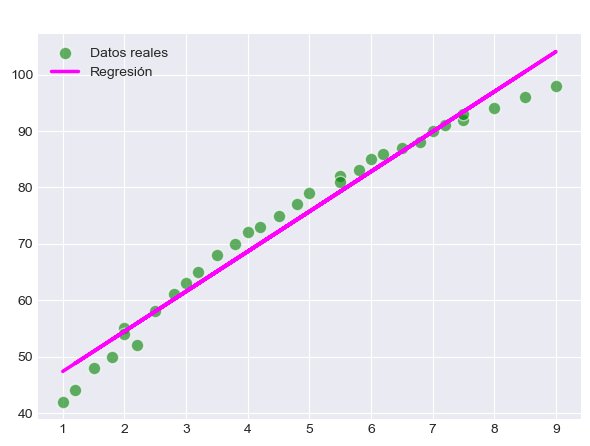

In [3]:
# Creamos un objeto de regresión lineal
linear_regressor = linear_model.LinearRegression()

# Ajustamos la regresión a los datos de entrenamiento
linear_regressor.fit(X_entrenamiento, Y_entrenamiento)

# Y a partir de datos de regresión encontrados
Y_predicha_de_entrenamiento = linear_regressor.predict(X_entrenamiento)

plt.style.use('seaborn-v0_8-darkgrid')
plt.figure(figsize=(7, 5))
plt.scatter(X_entrenamiento, Y_entrenamiento, color='green', alpha=0.6, edgecolors='white', s=80, label='Datos reales')
plt.plot(X_entrenamiento, Y_predicha_de_entrenamiento, color='magenta', linewidth=2.5, label='Regresión')
plt.title('Datos de entrenamiento', fontsize=16, color='white')
plt.legend()
plt.show()

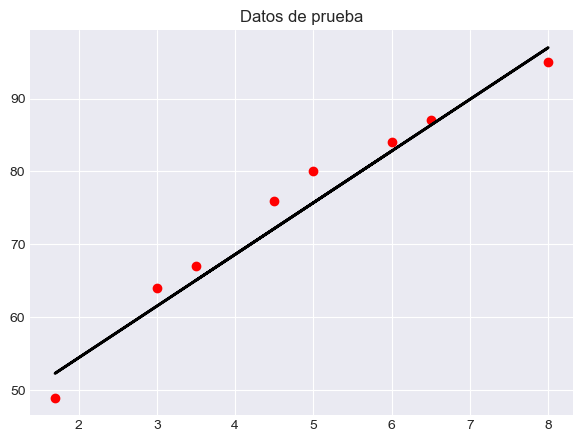

In [4]:
Y_predicha_de_prueba = linear_regressor.predict(X_prueba)
plt.figure(figsize=(7, 5))
plt.scatter(X_prueba, Y_prueba, color='red')
plt.plot(X_prueba, Y_predicha_de_prueba, color='black', linewidth=2)
plt.title('Datos de prueba')
plt.show()

In [5]:

print("Error absoluto medio =", round(sm.mean_absolute_error(Y_prueba, Y_predicha_de_prueba), 2))
print("Error cuadratico medio =", round(sm.mean_squared_error(Y_prueba, Y_predicha_de_prueba), 2))
print("Error absoluto mediano =", round(sm.median_absolute_error(Y_prueba, Y_predicha_de_prueba), 2))
print("Puntuación de varianza explicada =", round(sm.explained_variance_score(Y_prueba, Y_predicha_de_prueba), 2))
print("Puntuación R2 =", round(sm.r2_score(Y_prueba, Y_predicha_de_prueba), 2))

Error absoluto medio = 2.46
Error cuadratico medio = 7.45
Error absoluto mediano = 2.22
Puntuación de varianza explicada = 0.97
Puntuación R2 = 0.96


Error absoluto medio = 2.0
Error cuadratico medio = 6.17
Error absoluto mediano = 2.0
Puntuación de varianza explicada = 0.97
Puntuación R2 = 0.97


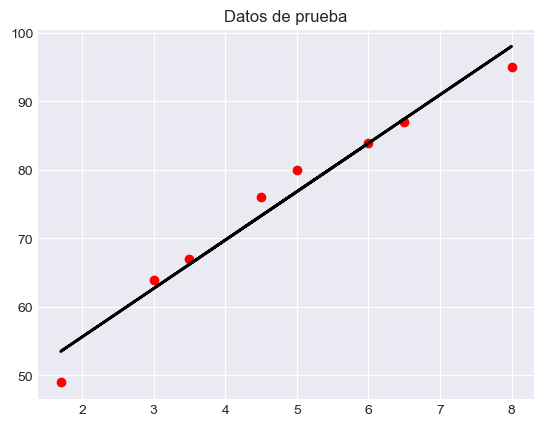

In [6]:
regresion_ridge = linear_model.Ridge(alpha=0.01, fit_intercept=True, max_iter=10000)
regresion_ridge.fit(X_prueba, Y_prueba)

Y_predicha_de_prueba = regresion_ridge.predict(X_prueba)

print("Error absoluto medio =", round(sm.mean_absolute_error(Y_prueba, Y_predicha_de_prueba), 2))
print("Error cuadratico medio =", round(sm.mean_squared_error(Y_prueba, Y_predicha_de_prueba), 2))
print("Error absoluto mediano =", round(sm.median_absolute_error(Y_prueba, Y_predicha_de_prueba), 2))
print("Puntuación de varianza explicada =", round(sm.explained_variance_score(Y_prueba, Y_predicha_de_prueba), 2))
print("Puntuación R2 =", round(sm.r2_score(Y_prueba, Y_predicha_de_prueba), 2))

plt.figure()
plt.scatter(X_prueba, Y_prueba, color='red')
plt.plot(X_prueba, Y_predicha_de_prueba, color='black', linewidth=2)
plt.title('Datos de prueba')
plt.show()

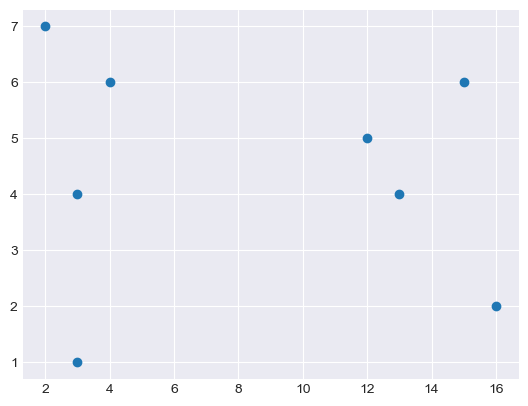

In [7]:
import numpy as np
from sklearn import linear_model
from sklearn import model_selection
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

X = np.array([[16,2], [3,1], [2,7], [13,4], [3,4], [12,5], [15,6], [4,6]])
plt.figure()
plt.scatter(X[:,0], X[:,1])
plt.show()

In [8]:
    Y = [1, 0, 0, 1, 0, 1, 1, 0]

In [9]:
clasificador = linear_model.LogisticRegression(solver='lbfgs', C=100)
clasificador.fit(X, Y)

LogisticRegression(C=100)

In [10]:
#El modelo predice las clases de los datos originales X. El resultado [1 0 0 1 0 1 1 0] es idéntico a Y, lo que significa que clasificó todo correctamente.
prediccion = clasificador.predict(X)
print(prediccion)
# [1 0 0 1 0 1 1 0]

[1 0 0 1 0 1 1 0]


In [11]:
#El score de 1.0 = 100% de precisión sobre los datos de entrenamiento. Clasificó todos los puntos sin errores.
print(clasificador.score(X, Y))
# 1.0

1.0


In [12]:
#Prueba
Xn = np.array([[6,4], [20,7], [4,17]])
Yn = clasificador.predict(Xn)
print(Yn)
# [0 1 0]

[0 1 0]


In [13]:
Xs = np.concatenate((X, Xn), axis=0)
Ys = np.append(Y, Yn)

x_min, x_max = min(Xs[:,0]) - 1.0, max(Xs[:,0]) + 1.0
y_min, y_max = min(Xs[:,1]) - 1.0, max(Xs[:,1]) + 1.0

In [14]:
step_size = 0.01

valor_x, valor_y = np.meshgrid(np.arange(x_min, x_max, step_size), np.arange(y_min, y_max, step_size))

malla_de_puntos = clasificador.predict(np.c_[valor_x.ravel(), valor_y.ravel()])

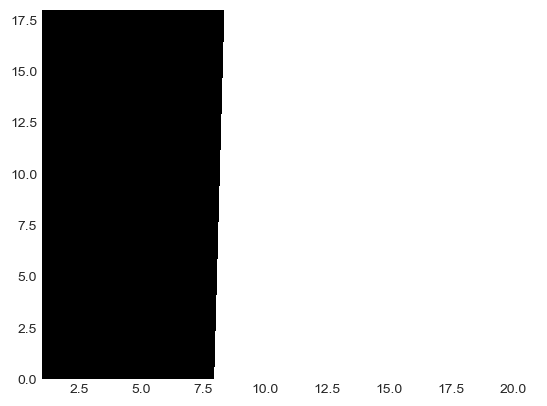

In [15]:
malla_de_puntos = malla_de_puntos.reshape(valor_x.shape)
plt.figure()
plt.pcolormesh(valor_x, valor_y, malla_de_puntos, cmap=plt.cm.gray, shading='auto')

[[  0.     31.875  63.75 ]
 [ 95.625 127.5   159.375]
 [191.25  223.125 255.   ]]


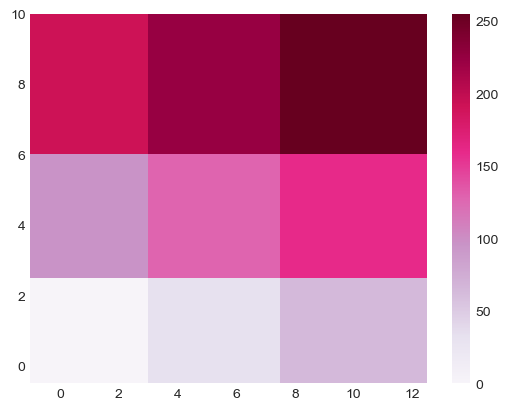

In [16]:
x = np.array([1, 5, 10])
y = np.array([1, 4, 8])
z = np.linspace(0, 255, 9).reshape(3, 3)
print(z)
plt.pcolormesh(x, y, z, cmap="PuRd", shading='auto')  #cmap = "PuRd"
plt.colorbar()

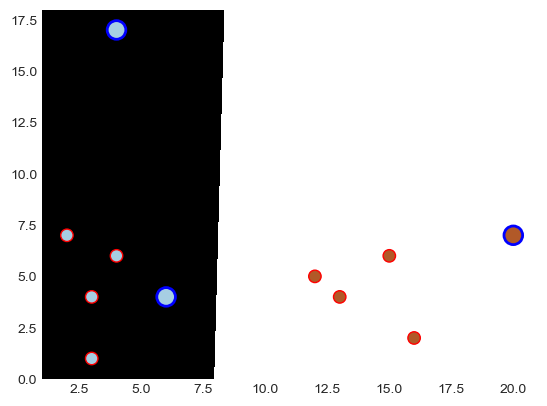

In [17]:
malla_de_puntos = malla_de_puntos.reshape(valor_x.shape)
plt.figure()
plt.pcolormesh(valor_x, valor_y, malla_de_puntos, cmap=plt.cm.gray, shading='auto')
plt.scatter(X[:, 0], X[:, 1], c=Y, s=80, edgecolors='red', linewidth=1, cmap=plt.cm.Paired)
plt.scatter(Xn[:, 0], Xn[:, 1], c=clasificador.predict(Xn), s=180, edgecolors='blue', linewidth=2,
            cmap=plt.cm.Paired)

plt.show()